In [1]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print(device)

2.11.0+cu128
cuda


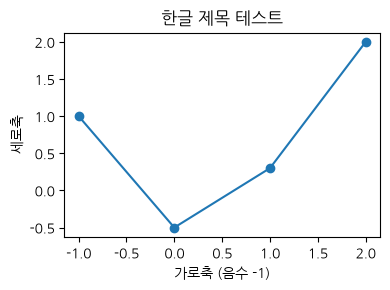

In [2]:
# 한글 폰트 설정 (나눔고딕)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_NAME = "NanumGothic"

# 설치된 폰트 목록에 나눔고딕이 있는지 확인
if FONT_NAME not in {f.name for f in fm.fontManager.ttflist}:
    # 혹시 폰트 캐시에 없으면 재스캔 시도
    fm._load_fontmanager(try_read_cache=False)

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 확인용 플롯
plt.figure(figsize=(4, 3))
plt.plot([-1, 0, 1, 2], [1, -0.5, 0.3, 2], marker="o")
plt.title("한글 제목 테스트")
plt.xlabel("가로축 (음수 -1)")
plt.ylabel("세로축")
plt.tight_layout()
plt.show()


In [3]:
# 데이터 경로 설정
PATH = './data'
IMG_DIR = os.path.join(PATH, 'images')
XML_DIR = os.path.join(PATH, 'annotations')

xml_files = sorted(os.path.join(XML_DIR, f) for f in os.listdir(XML_DIR) if f.endswith('.xml'))

print(len(xml_files))
print(xml_files[0])

5000
./data\annotations\hard_hat_workers0.xml


In [4]:
import xml.etree.ElementTree as ET

def extract_info_from_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    for boxes in root.iter("object"):
        label = boxes.find("name").text

        if label == "head" or label == "person": # 헬멧 미착용 라벨0
            return filename, 0

    return filename, 1 # 헬멧 착용 라벨 1

In [5]:
import cv2

img_data, label_data = [], []

t0 = time.time()

for xml_file in xml_files:
    filename, label = extract_info_from_xml(xml_file)

    img = cv2.imread(os.path.join(IMG_DIR, filename))
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_data.append(cv2.resize(img, (224, 224)))
    label_data.append(label)

img_data = np.array(img_data, dtype = np.uint8)
label_data = np.array(label_data, dtype = np.uint64)

print(time.time())
print(img_data.shape, img_data.dtype, img_data.nbytes)
print(label_data.shape)

1788411822.9927208
(5000, 224, 224, 3) uint8 752640000
(5000,)


In [6]:
from collections import Counter

counter = Counter(label_data.tolist())
n_unsafe, n_safe = counter[0], counter[1]

print(f"0 DANGER: {n_unsafe} {n_unsafe / len(label_data) * 100}")
print(f"1 SAFE: {n_safe} {n_safe / len(label_data) * 100}")
print(f"Unbalance Ratio: {max(n_unsafe, n_safe) / min(n_unsafe, n_safe): .2f}")

0 DANGER: 1060 21.2
1 SAFE: 3940 78.8
Unbalance Ratio:  3.72


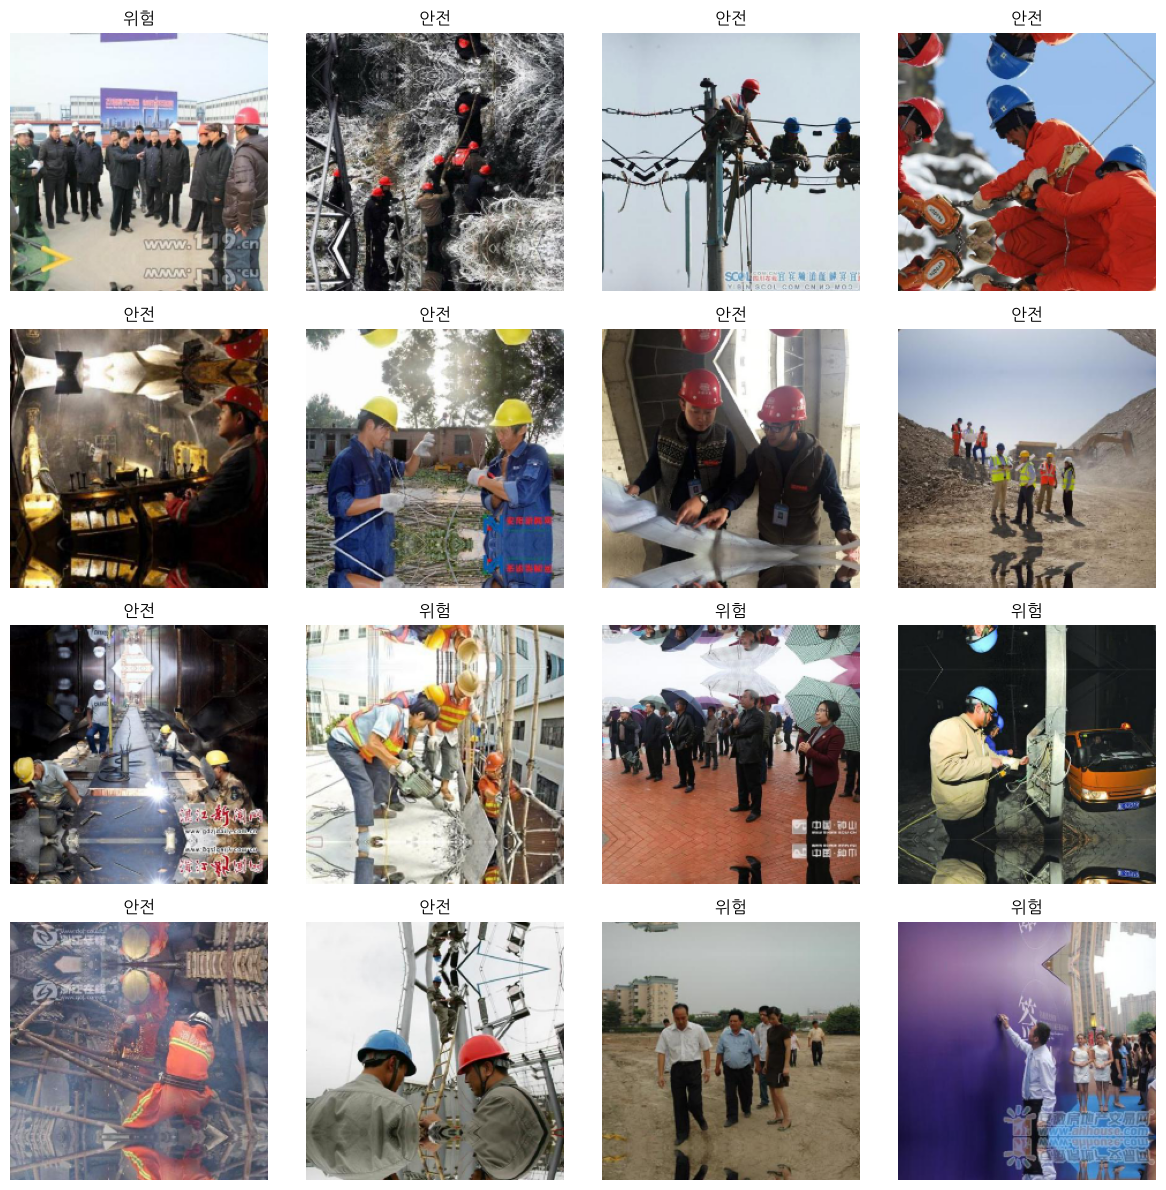

In [7]:
# 이미지랑 라벨링 제대로 되었는지 확인해야함.

labels_to_names = {
    0: "위험",
    1: "안전"
}

plt.figure(figsize = (12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(img_data[i])
    plt.title(labels_to_names[label_data[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

x_trainval, x_test, y_trainval, y_test = train_test_split(img_data, label_data, test_size = 0.1,
                                                  stratify = label_data, random_state = 42)

x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size = 0.2,
                                                  stratify = y_trainval, random_state = 42)

print(f"Train set: {len(x_train)}, Val set: {len(x_val)}, Test set: {len(x_test)}")

Train set: 3600, Val set: 900, Test set: 500


In [9]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype = np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype = np.float32)

class HelmetDataset(Dataset):
    def __init__(self, images, labels, normalize = "simple"):
        self.images = images
        self.labels = labels
        self.normalize = normalize

    def __len__(self):
        return len(self.images)

    # 이미지 전처리 함수
    # 이미지 normalize후 torch에서 쓸 수 있게 텐서 변환
    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0

        if self.normalize == "imagenet":
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        img = np.transpose(img, (2, 0, 1))

        return torch.from_numpy(img), torch.tensor(self.labels[idx], dtype = torch.float32)

# 이미지 로더 함수
def make_loader(normalize = "simple", batch_size = 32):
    tr = DataLoader(HelmetDataset(x_train, y_train, normalize), batch_size, shuffle = True)
    va = DataLoader(HelmetDataset(x_val, y_val, normalize), batch_size, shuffle = False)
    te = DataLoader(HelmetDataset(x_test, y_test, normalize), batch_size, shuffle = False)

    return tr, va, te

_tr, _, _ = make_loader()

xb, yb = next(iter(_tr))
print(f"입력 배치: {tuple(xb.shape)} {xb.type}")
print(f"라벨 배치: {tuple(yb.shape)} {yb.type}")
print(f"범위: {xb.min(): .3f} ~ {xb.max(): .3f}")

입력 배치: (32, 3, 224, 224) <built-in method type of Tensor object at 0x0000019D7D151B30>
라벨 배치: (32,) <built-in method type of Tensor object at 0x0000019D7C938FF0>
범위:  0.000 ~  1.000


In [10]:
# CNN Model

def conv_block(in_ch, out_ch):

    return [
        nn.Conv2d(in_ch, out_ch, kernel_size = 3),
        nn.ReLU(inplace = True),
        nn.BatchNorm2d(out_ch),

    ]

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            *conv_block(3, 64), *conv_block(64, 64), nn.MaxPool2d(2),
            *conv_block(64, 128), *conv_block(128, 128), nn.MaxPool2d(2),
            *conv_block(128, 256), *conv_block(256, 256), nn.MaxPool2d(2),
            *conv_block(256, 512), *conv_block(512, 512), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512 * 10 * 10, 1024),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def summarize(model, name = "model"):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    with torch.no_grad():
        out = model(torch.zeros(1, 3, 224, 224))

    print(name)
    print(f"출력 모양: {tuple(out.shape)}")
    print(f"전체 파라미터: {total: ,}")
    print(f"학습 파라미터: {trainable: ,}")
    print(f"고정 파라미터: {total - trainable: ,}")

base_model = BaseCNN()
summarize(base_model, "BaseCNN")

BaseCNN
출력 모양: (1, 1)
전체 파라미터:  57,120,065
학습 파라미터:  57,120,065
고정 파라미터:  0


In [11]:
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score)

@torch.no_grad()
def evaluate(model, loader, criterion = None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).squeeze(1) # output

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)

    preds = (probs > 0.5).astype(int)

    return {
        "loss": (sum(losses) / len(trues)) if criterion is not None else None,
        "accuracy": accuracy_score(trues, preds),
        "recall": recall_score(trues, preds, zero_division = 0),
        "precision": precision_score(trues, preds, zero_division = 0),
        "auc": roc_auc_score(trues, probs) if len(set(trues)) > 1 else float("nan"),
        "probs": probs,
        "trues": trues,
        "preds": preds
    }

def train_model(model, train_loader, val_loader, epochs = 20, lr = 1e-3, pos_weight = None, ckpt_path = "best_model.pt",
                label = "model"):
    model = model.to(device)
    pw = (None if pos_weight is None else torch.tensor([pos_weight], dtype = torch.float32, device = device))
    criterion = nn.BCEWithLogitsLoss(pos_weight = pw) # 두가지 분류할때 사용
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    history = {k: [] for k in ["loss", "val_loss", "accuracy", "val_accuracy", "val_recall", "val_precision", "val_auc"]}
    best_auc = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * len(yb)
            run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n

        m = evaluate(model, val_loader, criterion)

        history["loss"].append(tr_loss)
        history["accuracy"].append(tr_acc)
        history["val_loss"].append(m["loss"])
        history["val_accuracy"].append(m["accuracy"])
        history["val_recall"].append(m["recall"])
        history["val_precision"].append(m["precision"])
        history["val_auc"].append(m["auc"])

        star = ""
        if m["auc"] > best_auc:
            best_auc = m["auc"]
            torch.save(model.state_dict(), ckpt_path)
            star = "Saved!"

        print(f"[{label}] {epoch: 02d} / {epochs}")
        print(f"Loss: {tr_loss: .4f} Val_Loss: {m['loss']: .4f}")
        print(f"Val_Acc: {m['accuracy']: .4f} Val_Auc: {m['auc']: .4f}")
        print(f"{time.time() - t0: .0f} {star}")

    print(f"Best Val_auc = {best_auc: .4f} {ckpt_path}")
    return history

In [18]:
def plot_history(history, title):
    plt.figure(figsize = (6, 4))
    plt.plot(history['loss'], label = "train")
    plt.plot(history['val_loss'], label = "val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(alpha = 0.5)
    plt.tight_layout()
    plt.show()

def plot_confusion(model, loader, ckpt_path = None, title = "Confusion Matrix"):
    import seaborn as sns

    if ckpt_path is not None:
        model.load_state_dict(torch.load(ckpt_path, map_location = device))

    model = model.to(device)

    m = evaluate(model, loader)
    cm = confusion_matrix(m['trues'], m['preds'])

    plt.figure(figsize = (6, 5))
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", annot_kws = {"size": 16}, xticklabels = ["Danger", "Safe"],
                yticklabels = ["Danger", "Safe"])

    plt.xlabel("예측값")
    plt.ylabel("실제값")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print(f"Accuracy: {m['accuracy']: .4f} Recall: {m['recall']: .4f}")
    print(f"Precision: {m['precision']: .4f} AUC: {m['auc']: .4f}")

    return m

In [13]:
EPOCHS = 2

train_loader, val_loader, test_loader = make_loader(normalize = "simple", batch_size = 32)
base_model = BaseCNN()
base_history = train_model(base_model, train_loader, val_loader, epochs = EPOCHS,
                           lr = 1e-3, ckpt_path = "best_base_model.pt", label = "base")


[base]  1 / 2
Loss:  3.1432 Val_Loss:  1.4074
Val_Acc:  0.7356 Val_Auc:  0.5593
 31 Saved!
[base]  2 / 2
Loss:  0.9491 Val_Loss:  0.6008
Val_Acc:  0.7333 Val_Auc:  0.6188
 31 Saved!
Best Val_auc =  0.6188 best_base_model.pt


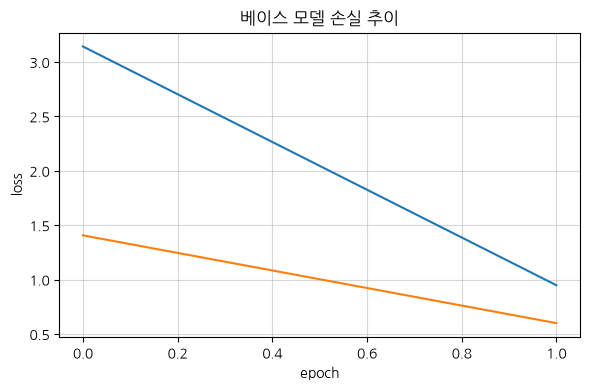

In [14]:
plot_history(base_history, "베이스 모델 손실 추이")

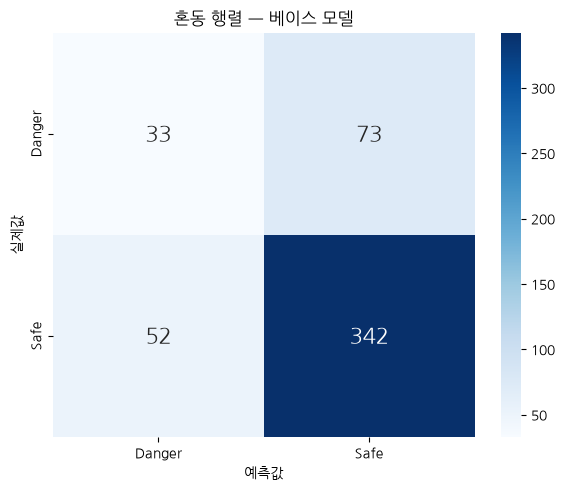

Accuracy:  0.7500 Recall:  0.8680
Precision:  0.8241 AUC:  0.6887


In [19]:
base_metrics = plot_confusion(BaseCNN(), test_loader, ckpt_path = "best_base_model.pt", title = "혼동 행렬 ㅡ 베이스 모델")

In [20]:
# 전이 학습

from torchvision import models

class TransferModel(nn.Module):
    def __init__(self, freeze = True):
        super().__init__()
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_v2_s(weights = weights)

        self.features = backbone.features

        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)

        return self.fc(self.dropout(x))

transfer_model = TransferModel(freeze = True)
summarize(transfer_model)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\KDS-11/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 88.9MB/s]


model
출력 모양: (1, 1)
전체 파라미터:  20,178,769
학습 파라미터:  1,281
고정 파라미터:  20,177,488


In [21]:
tr_loader, va_loader, te_loader = make_loader(normalize = "imagenet", batch_size = 32)

xb, _ = next(iter(tr_loader))
print(f"정규화 범위: {xb.min(): .3f} ~ {xb.max(): .3f}")


정규화 범위: -2.118 ~  2.640


In [26]:
transfer_model = TransferModel(freeze = True)
transfer_history = train_model(transfer_model, tr_loader, va_loader,
                               epochs = EPOCHS, lr = 5e-4, ckpt_path = "best_transfer_model.pt", label = "전이학습")

[전이학습]  1 / 2
Loss:  0.5131 Val_Loss:  0.4807
Val_Acc:  0.8133 Val_Auc:  0.7329
 13 Saved!
[전이학습]  2 / 2
Loss:  0.4609 Val_Loss:  0.4587
Val_Acc:  0.8300 Val_Auc:  0.7667
 13 Saved!
Best Val_auc =  0.7667 best_transfer_model.pt


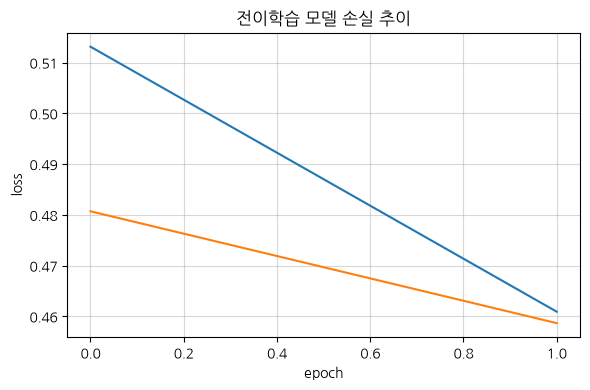

In [28]:
plot_history(transfer_history, "전이학습 모델 손실 추이")

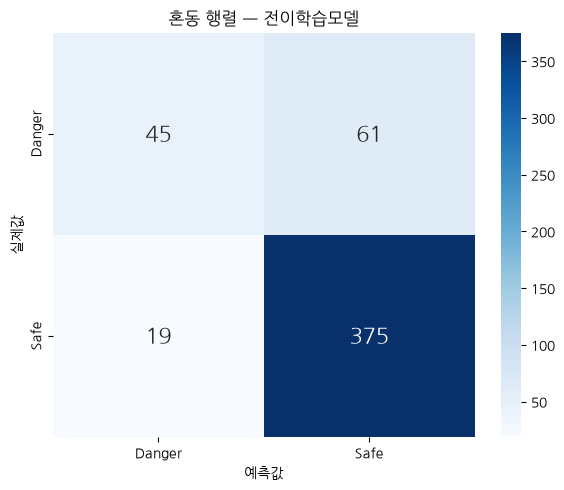

Accuracy:  0.8400 Recall:  0.9518
Precision:  0.8601 AUC:  0.7861


In [27]:
transfer_metrics = plot_confusion(TransferModel(freeze = True), te_loader, ckpt_path = "best_transfer_model.pt", title = "혼동 행렬 ㅡ 전이학습모델")

In [30]:
# 클래스 가중치 적용 (class_weight)

labels_int = np.asarray(label_data).astype(np.int64)
unsafe, safe = np.bincount(labels_int)
total = unsafe + safe

weight_for_unsafe = (1 / unsafe) * (total / 2.0)
weight_for_safe = (1 / safe) * (total / 2.0)

# 텐서로 만들때 dtype = torch.float32
pos_weight = weight_for_safe / weight_for_unsafe
print(pos_weight)

if pos_weight < 1:
    print("안전쪽에 벌점을 낮춘다.")

else:
    print("안전쪽에 벌점을 높인다.")

0.26903553299492383
안전쪽에 벌점을 낮춘다.


In [31]:
weighted_model = TransferModel(freeze = True)
weighted_history = train_model(
    weighted_model, tr_loader, va_loader, epochs = EPOCHS, lr = 5e-4, pos_weight = pos_weight,
    ckpt_path = "best_weighted_model.pt", label = "가중치적용"
)

[가중치적용]  1 / 2
Loss:  0.2717 Val_Loss:  0.2524
Val_Acc:  0.7522 Val_Auc:  0.7887
 15 Saved!
[가중치적용]  2 / 2
Loss:  0.2469 Val_Loss:  0.2399
Val_Acc:  0.7244 Val_Auc:  0.8023
 15 Saved!
Best Val_auc =  0.8023 best_weighted_model.pt


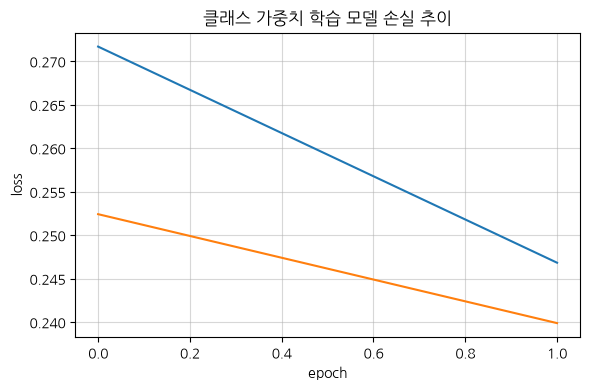

In [32]:
plot_history(weighted_history, "클래스 가중치 학습 모델 손실 추이")

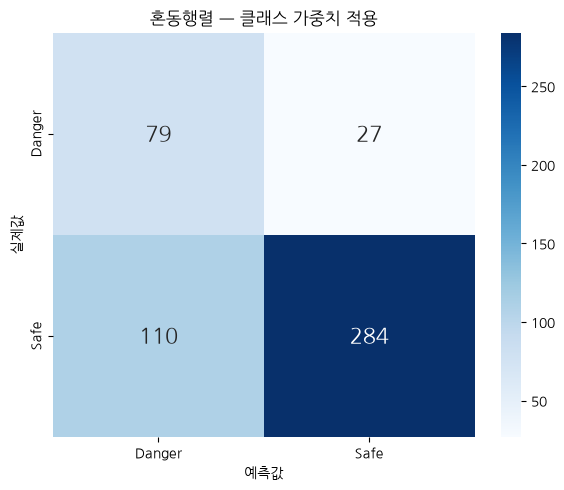

Accuracy:  0.7260 Recall:  0.7208
Precision:  0.9132 AUC:  0.8191


In [33]:
weighted_metrics = plot_confusion(TransferModel(freeze = True), te_loader, ckpt_path = "best_weighted_model.pt",
                                  title = "혼동행렬 ㅡ 클래스 가중치 적용")